In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("imdb-videogames.csv")

df.head()

,Unnamed: 0,name,url,year,certificate,rating,votes,plot,Action,Adventure,Comedy,Crime,Family,Fantasy,Mystery,Sci-Fi,Thriller
0,0,Spider-Man,https://www.imdb.com/title/tt5807780/?ref_=adv...,2018.0,T,9.2,"20,759","When a new villain threatens New York City, Pe...",True,True,False,False,False,True,False,False,False
1,1,Red Dead Redemption II,https://www.imdb.com/title/tt6161168/?ref_=adv...,2018.0,M,9.7,"35,703",Amidst the decline of the Wild West at the tur...,True,True,False,True,False,False,False,False,False
2,2,Grand Theft Auto V,https://www.imdb.com/title/tt2103188/?ref_=adv...,2013.0,M,9.5,"59,986",Three very different criminals team up for a s...,True,False,False,True,False,False,False,False,False
3,3,God of War,https://www.imdb.com/title/tt5838588/?ref_=adv...,2018.0,M,9.6,"26,118","After wiping out the gods of Mount Olympus, Kr...",True,True,False,False,False,False,False,False,False
4,4,Uncharted 4: A Thief's End,https://www.imdb.com/title/tt3334704/?ref_=adv...,2016.0,T,9.5,"28,722",Thrown back into the dangerous underworld he'd...,True,True,False,False,False,False,False,False,False


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20803 entries, 0 to 20802
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   20803 non-null  int64  
 1   name         20803 non-null  str    
 2   url          20803 non-null  str    
 3   year         20536 non-null  float64
 4   certificate  7903 non-null   str    
 5   rating       11600 non-null  float64
 6   votes        11600 non-null  str    
 7   plot         20803 non-null  str    
 8   Action       20803 non-null  bool   
 9   Adventure    20803 non-null  bool   
 10  Comedy       20803 non-null  bool   
 11  Crime        20803 non-null  bool   
 12  Family       20803 non-null  bool   
 13  Fantasy      20803 non-null  bool   
 14  Mystery      20803 non-null  bool   
 15  Sci-Fi       20803 non-null  bool   
 16  Thriller     20803 non-null  bool   
dtypes: bool(9), float64(2), int64(1), str(5)
memory usage: 4.9 MB


,Unnamed: 0,year,rating
count,20803.000000,20536.000000,11600.000000
mean,10401.000000,2005.568611,7.047526
std,6005.453161,11.846028,1.235204
min,0.000000,1952.000000,1.000000
25%,5200.500000,1997.000000,6.400000
50%,10401.000000,2008.000000,7.200000
75%,15601.500000,2016.000000,7.900000
max,20802.000000,2027.000000,9.700000


In [4]:
df.isnull().sum()

Unnamed: 0         0
name               0
url                0
year             267
certificate    12900
rating          9203
votes           9203
plot               0
Action             0
Adventure          0
Comedy             0
Crime              0
Family             0
Fantasy            0
Mystery            0
Sci-Fi             0
Thriller           0
dtype: int64

In [5]:
df.select_dtypes(include=['float64','int64'])

,Unnamed: 0,year,rating
0,0,2018.0,9.2
1,1,2018.0,9.7
2,2,2013.0,9.5
3,3,2018.0,9.6
4,4,2016.0,9.5
...,...,...,...
20798,20798,2014.0,NaN
20799,20799,2004.0,NaN
20800,20800,2015.0,NaN
20801,20801,2015.0,NaN


In [10]:
print(data.columns)

Index(['Unnamed: 0', 'name', 'url', 'year', 'certificate', 'rating', 'votes',
       'plot', 'Action', 'Adventure', 'Comedy', 'Crime', 'Family', 'Fantasy',
       'Mystery', 'Sci-Fi', 'Thriller'],
      dtype='str')


In [12]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Example dataset
data = {
    'age': [25, 30, 35, 40],
    'income': [50000, 60000, 65000, 70000]
}

df = pd.DataFrame(data)

# Define features
features = df[['age', 'income']]

# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print(scaled_features)

[[-1.34164079 -1.52127766]
 [-0.4472136  -0.16903085]
 [ 0.4472136   0.50709255]
 [ 1.34164079  1.18321596]]


In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

df = df.loc[features.index]
df['Cluster'] = clusters

df.head()

,age,income,Cluster
0,25,50000,2
1,30,60000,0
2,35,65000,0
3,40,70000,1


In [14]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

df['PCA1'] = pca_features[:,0]
df['PCA2'] = pca_features[:,1]

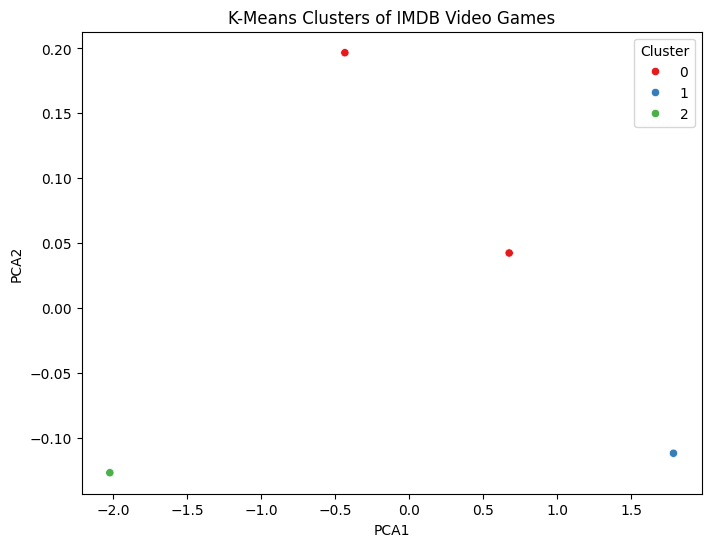

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set1',
    data=df
)

plt.title("K-Means Clusters of IMDB Video Games")
plt.show()

In [16]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(centers, columns=features.columns)

centers_df

,age,income
0,32.5,62500.0
1,40.0,70000.0
2,25.0,50000.0
